# Task
Analyze the "bank.csv" dataset to predict personal loan acceptance, covering data loading and exploration, handling missing values, initial categorical encoding, exploratory data analysis (EDA), data preprocessing for modeling, training and evaluating Logistic Regression and Decision Tree models, and deriving business insights.

## Load and Explore Data

### Subtask:
Load the 'bank.csv' dataset into a Pandas DataFrame. Display the first few rows, print the dataset information (.info()) and summary statistics (.describe()), and clearly identify categorical and numerical features present in the dataset.


In [1]:
import pandas as pd

df = pd.read_csv('/content/bank.csv', sep=';')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

First 5 rows of the DataFrame:
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 e

### Categorical and Numerical Features

Based on the `df.info()` output, we can identify the following features:

**Numerical Features (Dtype: int64):**
- `age`
- `balance`
- `day`
- `duration`
- `campaign`
- `pdays`
- `previous`

**Categorical Features (Dtype: object):**
- `job`
- `marital`
- `education`
- `default`
- `housing`
- `loan`
- `contact`
- `month`
- `poutcome`
- `y`

## Handle Missing Values and Initial Categorical Encoding

### Subtask:
Check for missing values and perform initial encoding of categorical variables 'job', 'marital', and 'education' using one-hot encoding, preparing them for EDA.


In [2]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [3]:
columns_to_encode = ['job', 'marital', 'education']
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=False)

print("First 5 rows of the DataFrame after one-hot encoding:")
print(df_encoded.head())

print("\nDataFrame Information after encoding:")
df_encoded.info()

First 5 rows of the DataFrame after one-hot encoding:
   age default  balance housing loan   contact  day month  duration  campaign  \
0   30      no     1787      no   no  cellular   19   oct        79         1   
1   33      no     4789     yes  yes  cellular   11   may       220         1   
2   35      no     1350     yes   no  cellular   16   apr       185         1   
3   30      no     1476     yes  yes   unknown    3   jun       199         4   
4   59      no        0     yes   no   unknown    5   may       226         1   

   ...  job_technician  job_unemployed job_unknown marital_divorced  \
0  ...           False            True       False            False   
1  ...           False           False       False            False   
2  ...           False           False       False            False   
3  ...           False           False       False            False   
4  ...           False           False       False            False   

   marital_married  marital_sing

In [5]:
df = df_encoded.copy()

print("First 5 rows of the DataFrame after dropping original columns:")
print(df.head())

print("\nDataFrame Information after dropping original columns:")
df.info()

First 5 rows of the DataFrame after dropping original columns:
   age default  balance housing loan   contact  day month  duration  campaign  \
0   30      no     1787      no   no  cellular   19   oct        79         1   
1   33      no     4789     yes  yes  cellular   11   may       220         1   
2   35      no     1350     yes   no  cellular   16   apr       185         1   
3   30      no     1476     yes  yes   unknown    3   jun       199         4   
4   59      no        0     yes   no   unknown    5   may       226         1   

   ...  job_technician  job_unemployed job_unknown marital_divorced  \
0  ...           False            True       False            False   
1  ...           False           False       False            False   
2  ...           False           False       False            False   
3  ...           False           False       False            False   
4  ...           False           False       False            False   

   marital_married  mar

## Perform Exploratory Data Analysis (EDA)

### Subtask:
Visualize the relationships between the target variable (loan acceptance) and key features such as 'Age', 'Job', 'Marital Status', and 'Education'. Use bar plots, count plots, and correlation heatmaps to identify patterns of customers more likely to accept a loan. Ensure all plots include appropriate labels and legends for clarity.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert target variable 'y' to numerical (1 for 'yes', 0 for 'no')
df['y'] = df['y'].map({'yes': 1, 'no': 0})

print("First 5 rows of DataFrame after converting 'y' column:")
print(df.head())

print("\nValue counts for the 'y' column:")
print(df['y'].value_counts())

First 5 rows of DataFrame after converting 'y' column:
   age default  balance housing loan   contact  day month  duration  campaign  \
0   30      no     1787      no   no  cellular   19   oct        79         1   
1   33      no     4789     yes  yes  cellular   11   may       220         1   
2   35      no     1350     yes   no  cellular   16   apr       185         1   
3   30      no     1476     yes  yes   unknown    3   jun       199         4   
4   59      no        0     yes   no   unknown    5   may       226         1   

   ...  job_technician  job_unemployed job_unknown  marital_divorced  \
0  ...           False            True       False             False   
1  ...           False           False       False             False   
2  ...           False           False       False             False   
3  ...           False           False       False             False   
4  ...           False           False       False             False   

   marital_married  marit

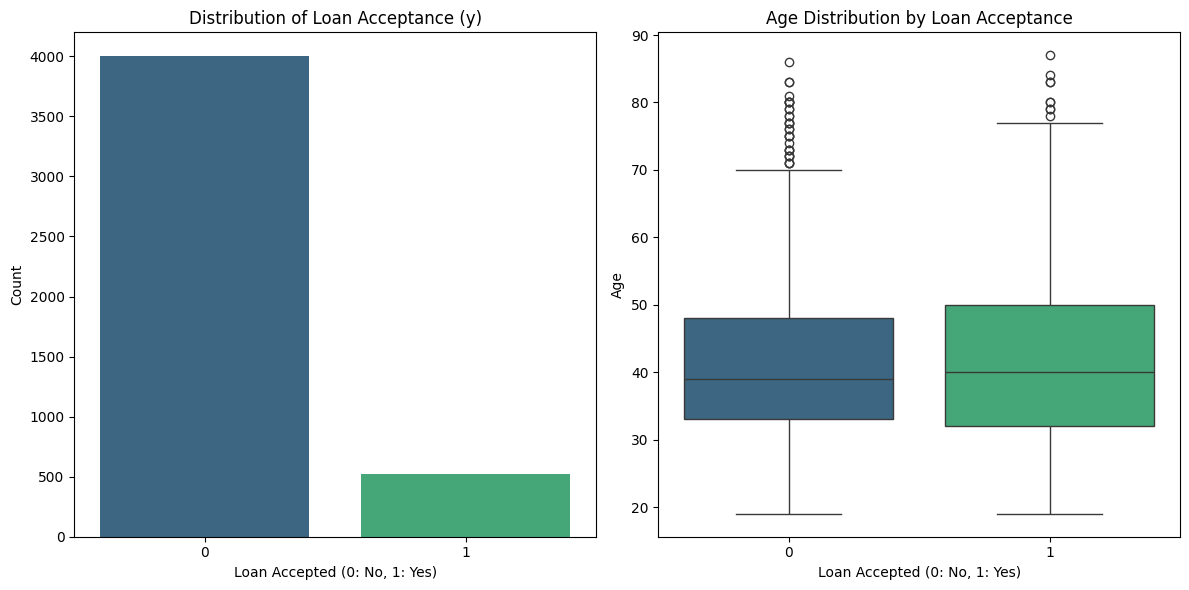

In [8]:
plt.figure(figsize=(12, 6))

# 1. Count plot for target variable 'y'
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x='y', data=df, palette='viridis', hue='y', legend=False)
plt.title('Distribution of Loan Acceptance (y)')
plt.xlabel('Loan Accepted (0: No, 1: Yes)')
plt.ylabel('Count')

# 2. Box plot for 'age' vs. 'y'
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(x='y', y='age', data=df, palette='viridis', hue='y', legend=False)
plt.title('Age Distribution by Loan Acceptance')
plt.xlabel('Loan Accepted (0: No, 1: Yes)')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

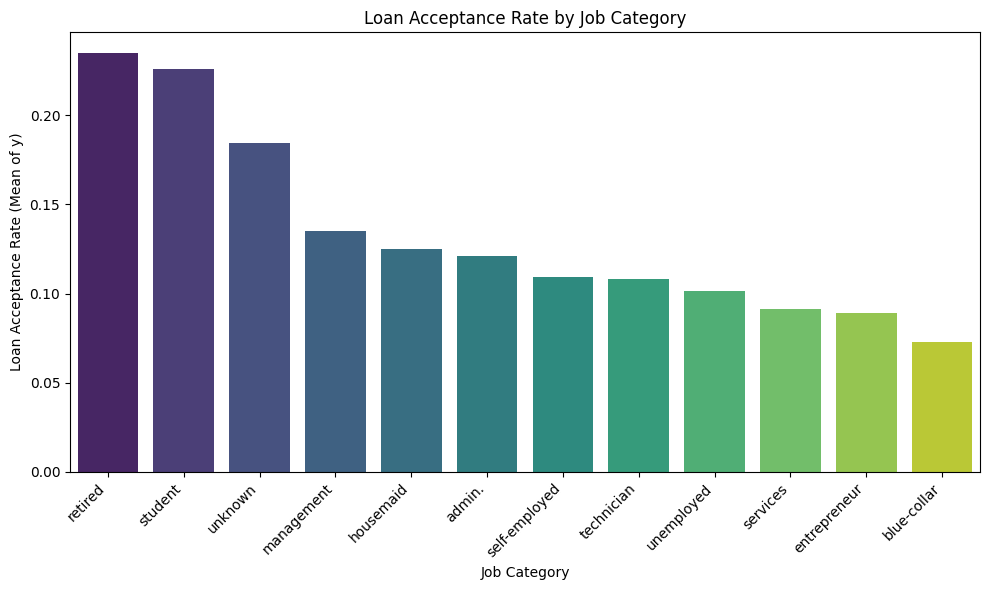

In [10]:
plt.figure(figsize=(10, 6))

# Calculate loan acceptance rate for each job category
job_cols = [col for col in df.columns if col.startswith('job_')]

job_acceptance_data = []
for col in job_cols:
    category_name = col.replace('job_', '')
    acceptance_rate = df[df[col] == True]['y'].mean()
    job_acceptance_data.append({'job_category': category_name, 'acceptance_rate': acceptance_rate})

job_acceptance_df = pd.DataFrame(job_acceptance_data)
job_acceptance_df = job_acceptance_df.sort_values(by='acceptance_rate', ascending=False)

sns.barplot(x='job_category', y='acceptance_rate', data=job_acceptance_df, palette='viridis', hue='job_category', legend=False)
plt.title('Loan Acceptance Rate by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Loan Acceptance Rate (Mean of y)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

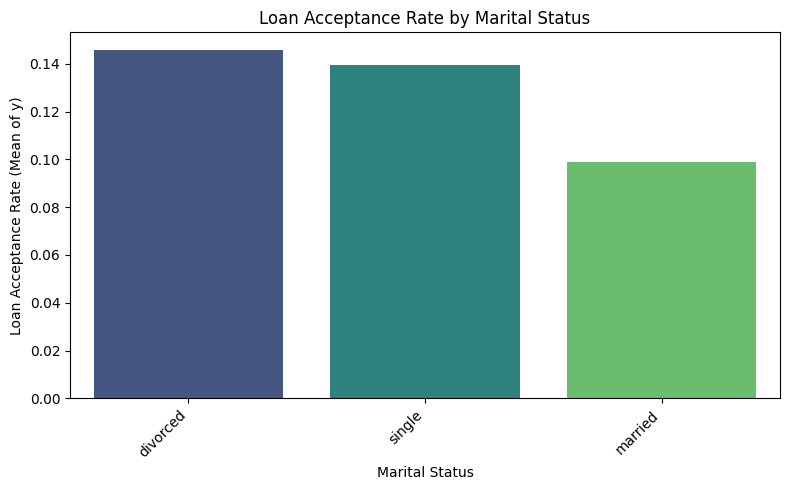

In [11]:
plt.figure(figsize=(8, 5))

# Calculate loan acceptance rate for each marital status category
marital_cols = [col for col in df.columns if col.startswith('marital_')]

marital_acceptance_data = []
for col in marital_cols:
    category_name = col.replace('marital_', '')
    acceptance_rate = df[df[col] == True]['y'].mean()
    marital_acceptance_data.append({'marital_category': category_name, 'acceptance_rate': acceptance_rate})

marital_acceptance_df = pd.DataFrame(marital_acceptance_data)
marital_acceptance_df = marital_acceptance_df.sort_values(by='acceptance_rate', ascending=False)

sns.barplot(x='marital_category', y='acceptance_rate', data=marital_acceptance_df, palette='viridis', hue='marital_category', legend=False)
plt.title('Loan Acceptance Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Loan Acceptance Rate (Mean of y)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Now, I will calculate and visualize the loan acceptance rate for each category within the 'education' feature, following the pattern established for 'job' and 'marital' features. This involves iterating through the one-hot encoded education columns, calculating the mean 'y' for each, and then plotting these rates.



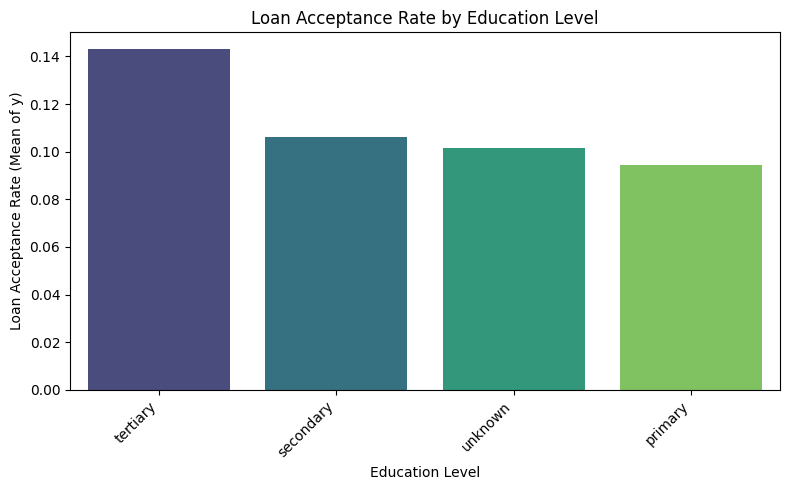

In [12]:
plt.figure(figsize=(8, 5))

# Calculate loan acceptance rate for each education category
education_cols = [col for col in df.columns if col.startswith('education_')]

education_acceptance_data = []
for col in education_cols:
    category_name = col.replace('education_', '')
    acceptance_rate = df[df[col] == True]['y'].mean()
    education_acceptance_data.append({'education_category': category_name, 'acceptance_rate': acceptance_rate})

education_acceptance_df = pd.DataFrame(education_acceptance_data)
education_acceptance_df = education_acceptance_df.sort_values(by='acceptance_rate', ascending=False)

sns.barplot(x='education_category', y='acceptance_rate', data=education_acceptance_df, palette='viridis', hue='education_category', legend=False)
plt.title('Loan Acceptance Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Loan Acceptance Rate (Mean of y)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Next, I will visualize the distribution of loan acceptance across the remaining object-type categorical features: 'default', 'housing', 'loan', 'contact', 'month', and 'poutcome'. For each of these features, I will generate a count plot with `hue='y'` to illustrate the proportion of loan acceptances within each category.



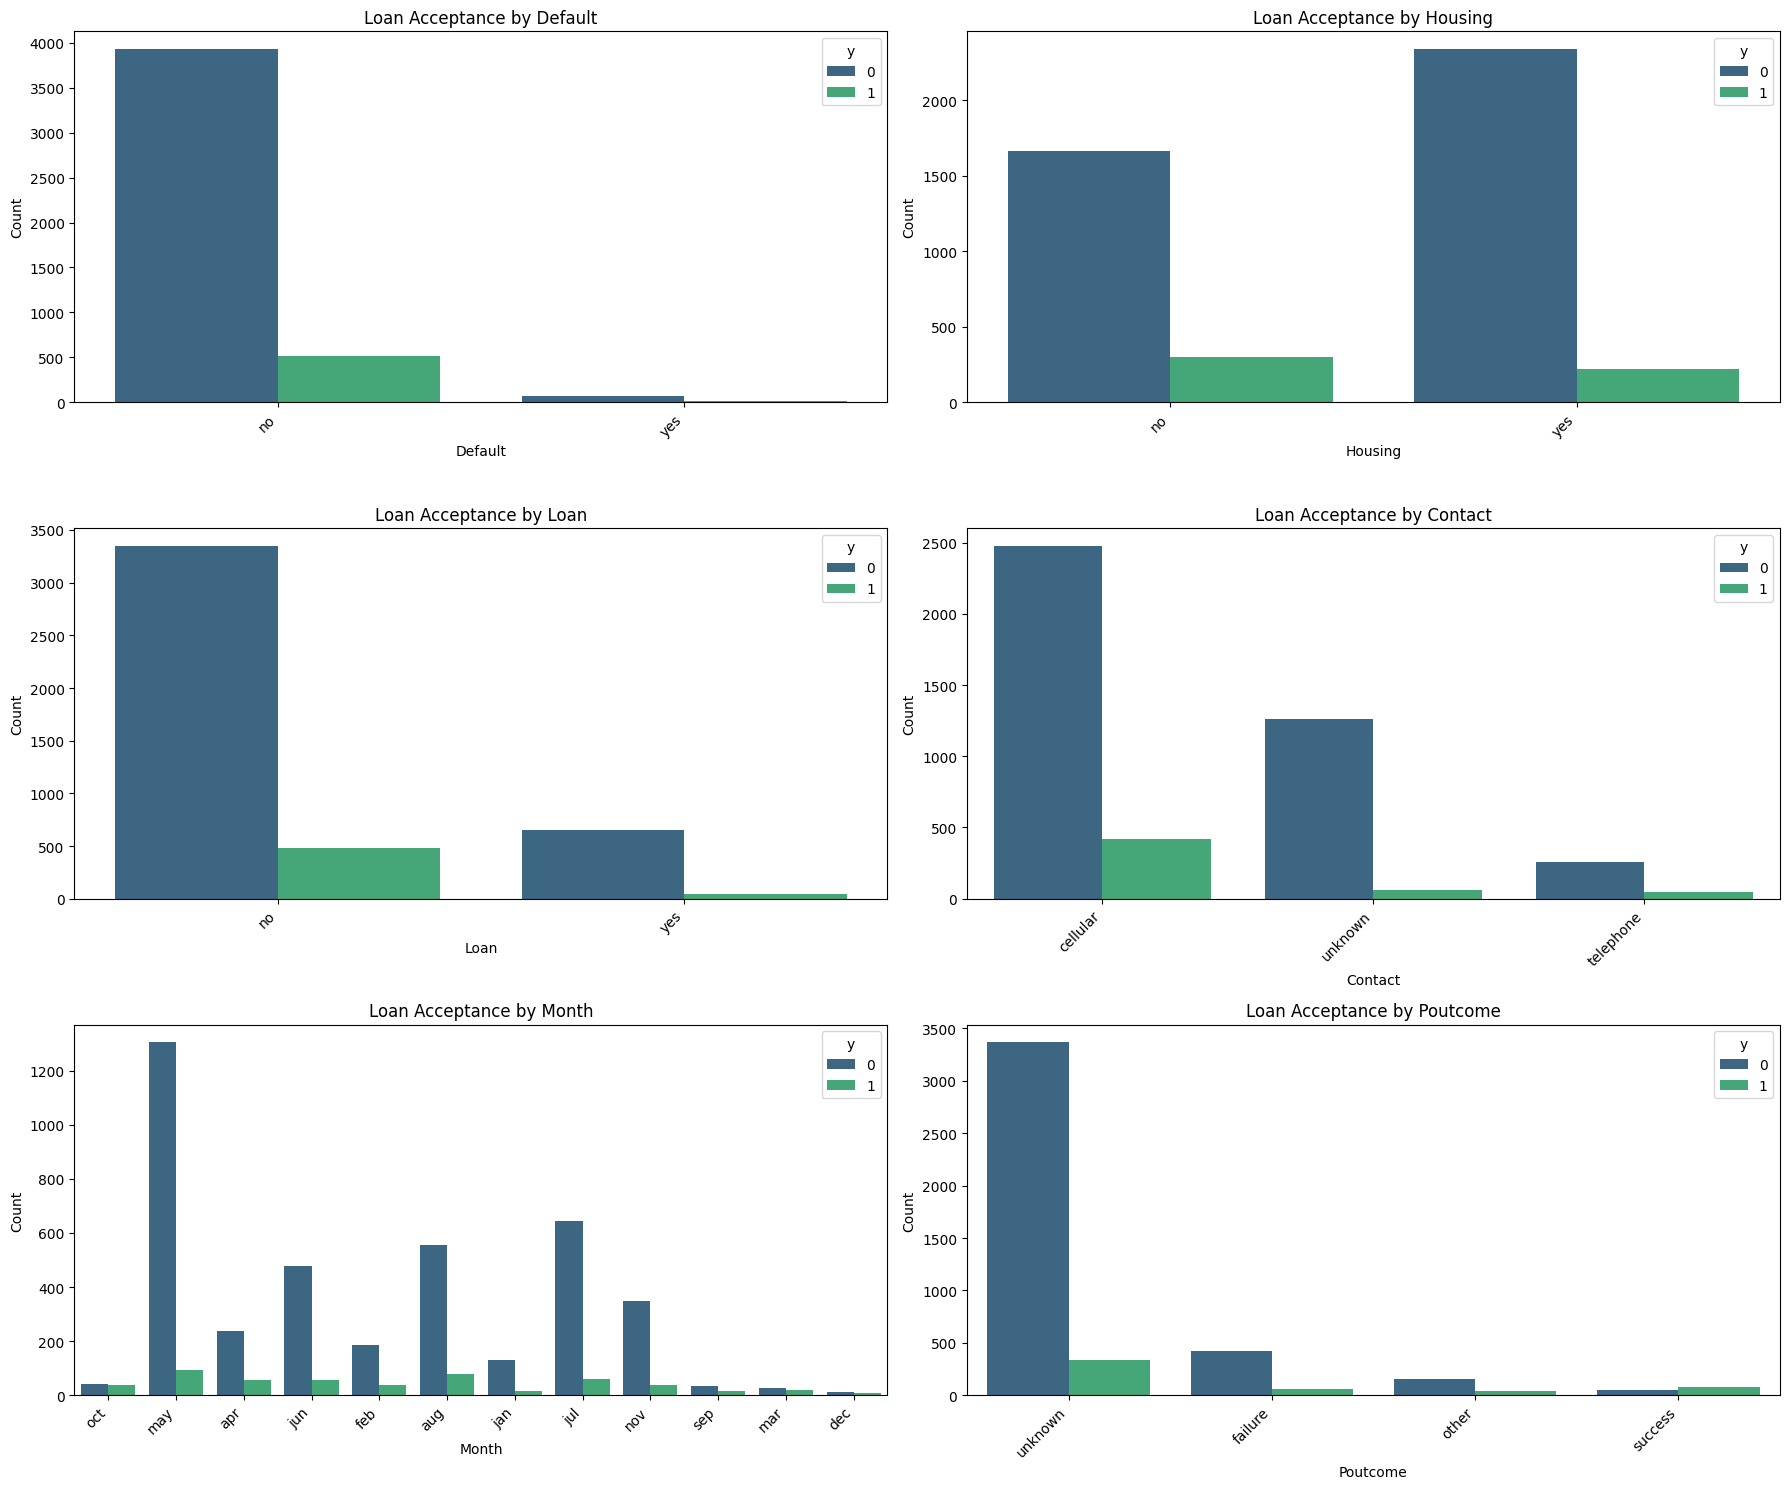

In [13]:
object_cols = ['default', 'housing', 'loan', 'contact', 'month', 'poutcome']

plt.figure(figsize=(18, 15))

for i, col in enumerate(object_cols):
    plt.subplot(3, 2, i + 1) # Arrange plots in 3 rows, 2 columns
    sns.countplot(x=col, hue='y', data=df, palette='viridis')
    plt.title(f'Loan Acceptance by {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    if col == 'month': # For months, ensure all labels are visible
        plt.tick_params(axis='x', labelbottom=True)

plt.tight_layout()
plt.show()


Now, I will generate a correlation heatmap for all numerical and one-hot encoded features, including the numerical target variable 'y', as specified in the subtask. This will help identify linear relationships between features and the target variable.



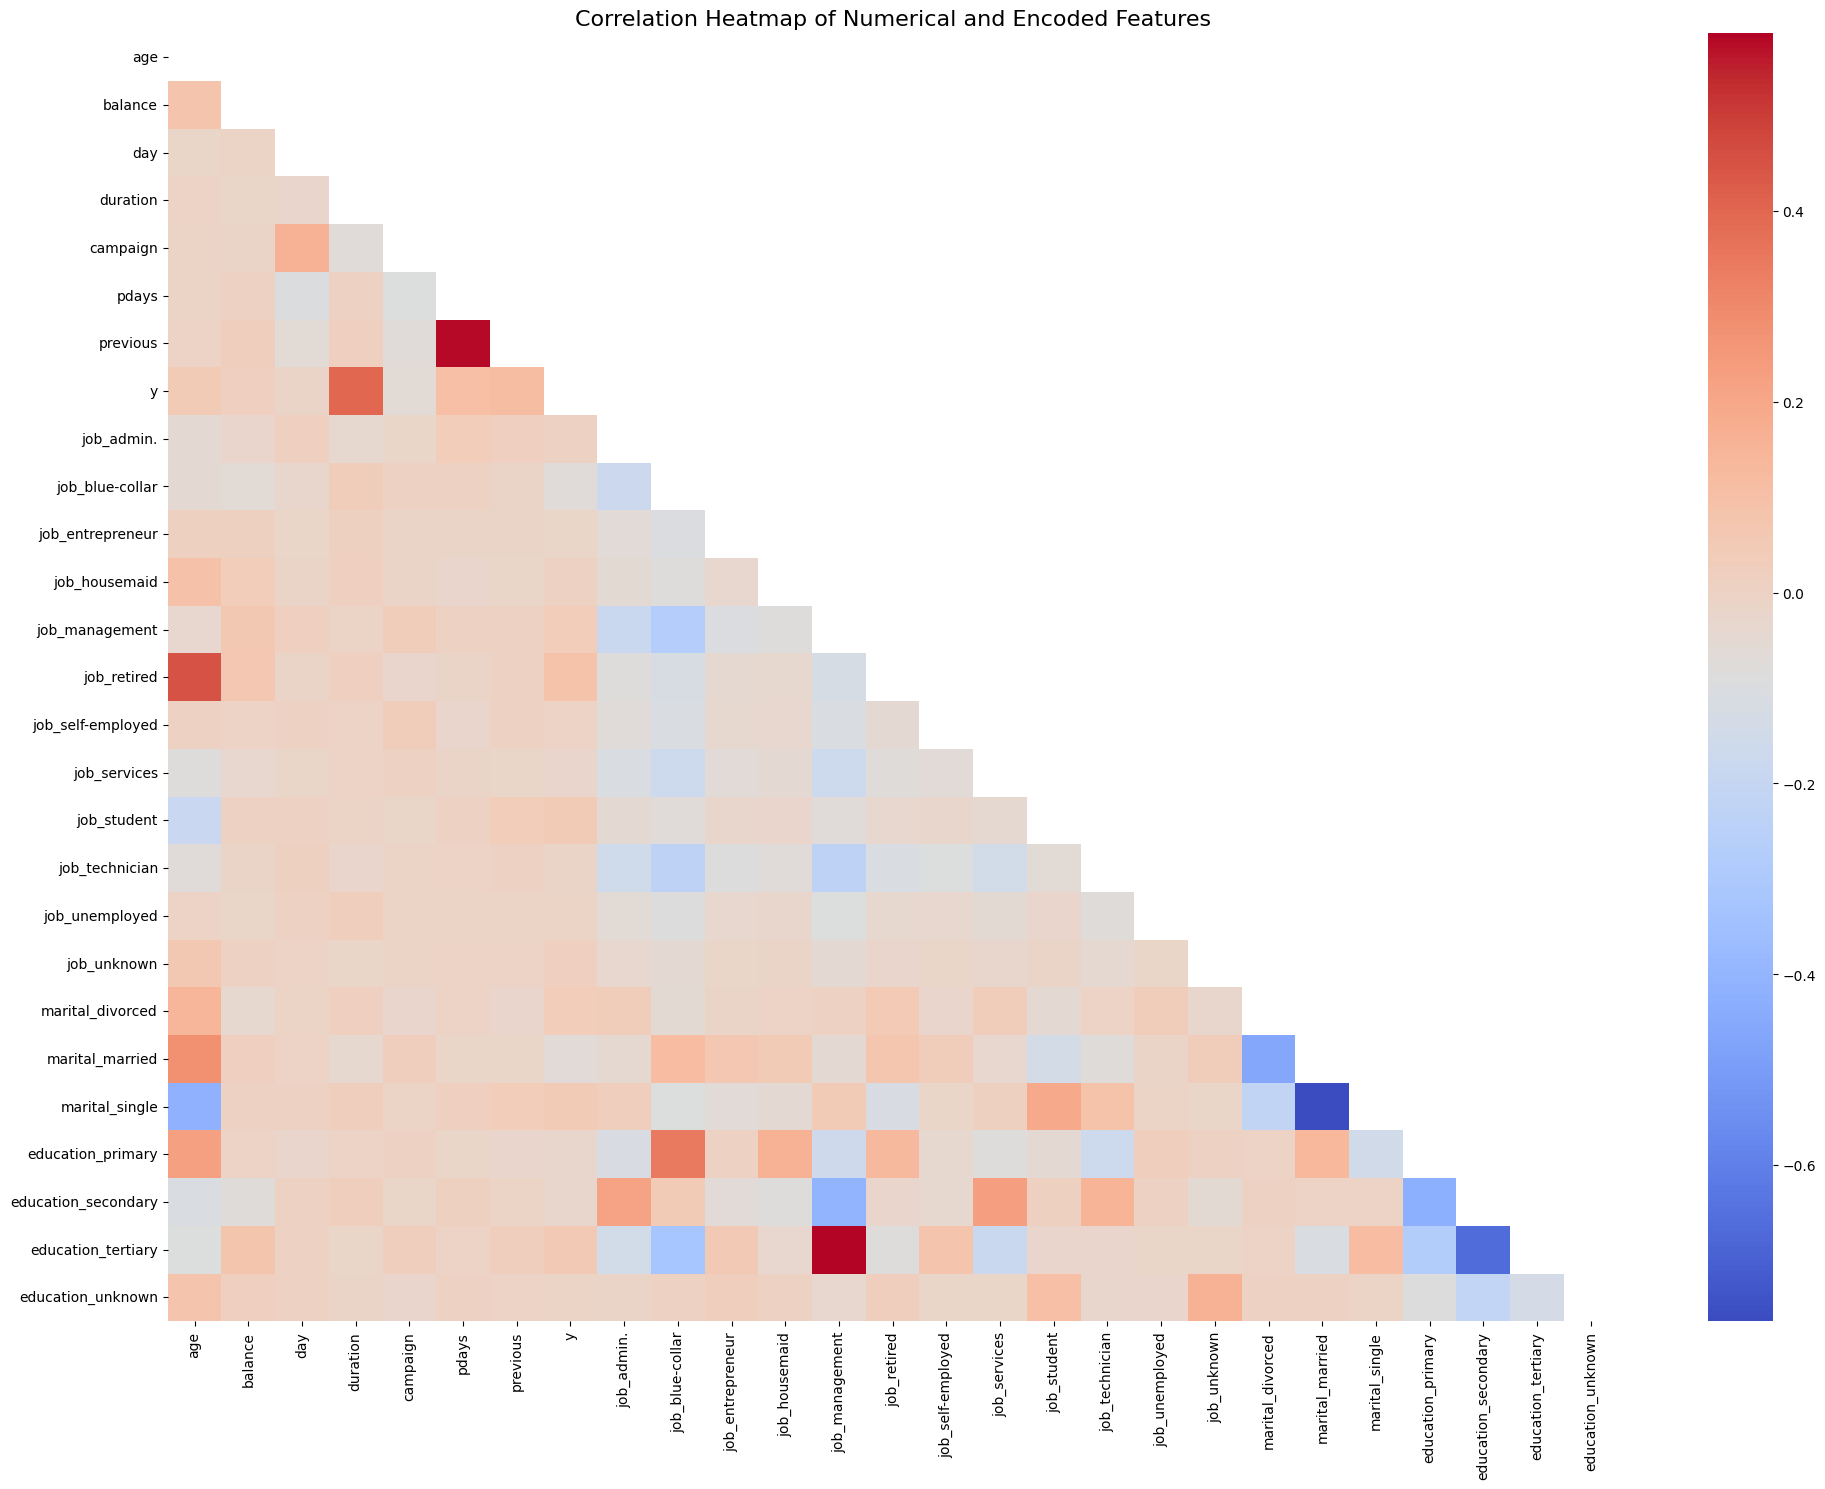

In [15]:
import numpy as np

plt.figure(figsize=(20, 15))

# Select all numerical and one-hot encoded columns, including the target 'y'
# 'df.select_dtypes(include=["number", "bool"])' will select int64 and bool columns
numerical_and_encoded_cols = df.select_dtypes(include=["number", "bool"]).columns.tolist()

# Calculate the correlation matrix
correlation_matrix = df[numerical_and_encoded_cols].corr()

# Plot the heatmap. Mask the upper triangle for better readability.
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Correlation Heatmap of Numerical and Encoded Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Preprocess Data for Modeling

### Subtask:
Convert all remaining categorical features into numerical format using appropriate encoding techniques (e.g., One-Hot Encoding for nominal variables, Label Encoding for ordinal variables if applicable). Split the processed dataset into training and testing sets (e.g., 80% train, 20% test) to prepare for model training.


In [16]:
remaining_object_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Remaining object columns to encode: {remaining_object_cols}")

df = pd.get_dummies(df, columns=remaining_object_cols, drop_first=False)

print("\nFirst 5 rows of the DataFrame after one-hot encoding remaining object columns:")
print(df.head())

print("\nDataFrame Information after encoding all categorical features:")
df.info()

Remaining object columns to encode: ['default', 'housing', 'loan', 'contact', 'month', 'poutcome']

First 5 rows of the DataFrame after one-hot encoding remaining object columns:
   age  balance  day  duration  campaign  pdays  previous  y  job_admin.  \
0   30     1787   19        79         1     -1         0  0       False   
1   33     4789   11       220         1    339         4  0       False   
2   35     1350   16       185         1    330         1  0       False   
3   30     1476    3       199         4     -1         0  0       False   
4   59        0    5       226         1     -1         0  0       False   

   job_blue-collar  ...  month_jun  month_mar  month_may  month_nov  \
0            False  ...      False      False      False      False   
1            False  ...      False      False       True      False   
2            False  ...      False      False      False      False   
3            False  ...       True      False      False      False   
4        

**Reasoning**:
Now that all categorical features are encoded, I will separate the features (X) from the target variable (y) and then split the data into training and testing sets using `train_test_split` from `sklearn.model_selection` to prepare for model training.



In [17]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('y', axis=1)
y = df['y']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (3616, 51)
Shape of X_test: (905, 51)
Shape of y_train: (3616,)
Shape of y_test: (905,)


## Train Machine Learning Models

### Subtask:
Train two classification models: a Logistic Regression classifier and a Decision Tree classifier using the preprocessed training data. Use default parameters initially.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 2. Instantiate a Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)

# 3. Fit the Logistic Regression model to the training data
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# 4. Instantiate a Decision Tree Classifier model
dec_tree_model = DecisionTreeClassifier(random_state=42)

# 5. Fit the Decision Tree model to the training data
dec_tree_model.fit(X_train, y_train)
print("Decision Tree model trained.")

Logistic Regression model trained.
Decision Tree model trained.


## Evaluate Model Performance

### Subtask:
Evaluate the performance of both the Logistic Regression and Decision Tree models on the test set. Calculate and display key metrics including accuracy scores, confusion matrices, and classification reports for each model. Provide a clear comparison of their performance.


In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate Logistic Regression Model
print("\n--- Logistic Regression Model Evaluation ---")
# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate and print Accuracy Score
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Accuracy Score: {log_reg_accuracy:.4f}")

# Calculate and print Confusion Matrix
log_reg_conf_matrix = confusion_matrix(y_test, y_pred_log_reg)
print("Confusion Matrix:")
print(log_reg_conf_matrix)

# Calculate and print Classification Report
log_reg_class_report = classification_report(y_test, y_pred_log_reg)
print("Classification Report:")
print(log_reg_class_report)

# Evaluate Decision Tree Model
print("\n--- Decision Tree Model Evaluation ---")
# Make predictions on the test set
y_pred_dec_tree = dec_tree_model.predict(X_test)

# Calculate and print Accuracy Score
dec_tree_accuracy = accuracy_score(y_test, y_pred_dec_tree)
print(f"Accuracy Score: {dec_tree_accuracy:.4f}")

# Calculate and print Confusion Matrix
dec_tree_conf_matrix = confusion_matrix(y_test, y_pred_dec_tree)
print("Confusion Matrix:")
print(dec_tree_conf_matrix)

# Calculate and print Classification Report
dec_tree_class_report = classification_report(y_test, y_pred_dec_tree)
print("Classification Report:")
print(dec_tree_class_report)


--- Logistic Regression Model Evaluation ---
Accuracy Score: 0.9017
Confusion Matrix:
[[789  18]
 [ 71  27]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       807
           1       0.60      0.28      0.38        98

    accuracy                           0.90       905
   macro avg       0.76      0.63      0.66       905
weighted avg       0.88      0.90      0.88       905


--- Decision Tree Model Evaluation ---
Accuracy Score: 0.8917
Confusion Matrix:
[[754  53]
 [ 45  53]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       807
           1       0.50      0.54      0.52        98

    accuracy                           0.89       905
   macro avg       0.72      0.74      0.73       905
weighted avg       0.90      0.89      0.89       905



## Derive Business Insights

### Subtask:
Analyze which customer groups are more likely to accept a personal loan offer, extracting actionable business insights from EDA and model results, and summarizing findings for marketing strategies.


In [20]:
print("--- Logistic Regression Model Coefficients ---")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg_model.coef_[0]})
coefficients['Absolute_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

print(coefficients.head(10)) # Display top 10 influential features
print("\n")
print(coefficients.tail(10)) # Display least 10 influential features

--- Logistic Regression Model Coefficients ---
             Feature  Coefficient  Absolute_Coefficient
49  poutcome_success     1.430111              1.430111
45         month_oct     1.147697              1.147697
42         month_mar     1.070577              1.070577
50  poutcome_unknown    -1.043764              1.043764
34   contact_unknown    -1.034147              1.034147
47  poutcome_failure    -0.922495              0.922495
39         month_jan    -0.874212              0.874212
44         month_nov    -0.852058              0.852058
40         month_jul    -0.780445              0.780445
43         month_may    -0.774838              0.774838


             Feature  Coefficient  Absolute_Coefficient
11    job_management     0.026327              0.026327
38         month_feb     0.023153              0.023153
2                day     0.012374              0.012374
35         month_apr     0.005968              0.005968
6           previous     0.005847              0.005847

**Reasoning**:
To understand the impact of features on loan acceptance for the Decision Tree model, I will extract and display its feature importances. This will help identify which features were most critical in the model's predictions.



In [21]:
print("--- Decision Tree Model Feature Importances ---")
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': dec_tree_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print(feature_importances.head(10)) # Display top 10 influential features
print("\n")
print(feature_importances.tail(10)) # Display least 10 influential features

--- Decision Tree Model Feature Importances ---
               Feature  Importance
3             duration    0.269354
2                  day    0.100297
49    poutcome_success    0.095290
0                  age    0.091358
1              balance    0.068197
5                pdays    0.040180
4             campaign    0.029385
24  education_tertiary    0.027122
45           month_oct    0.017679
6             previous    0.015570


              Feature  Importance
15        job_student    0.003047
48     poutcome_other    0.002884
37          month_dec    0.002471
22  education_primary    0.002008
13  job_self-employed    0.001608
17     job_unemployed    0.000562
27        default_yes    0.000000
40          month_jul    0.000000
47   poutcome_failure    0.000000
50   poutcome_unknown    0.000000


### Business Insights and Marketing Strategies

Based on the Exploratory Data Analysis (EDA) and the model evaluations (Logistic Regression coefficients and Decision Tree feature importances), we can identify several key customer characteristics associated with a higher likelihood of personal loan acceptance. This information can be leveraged to formulate targeted marketing strategies.

#### Key Customer Characteristics for Loan Acceptance:

1.  **Previous Campaign Outcome (`poutcome_success`)**: This is consistently the strongest predictor across both models, with `poutcome_success` having a very high positive coefficient in Logistic Regression and being a top feature in Decision Tree importance. Customers who previously accepted a loan offer (`poutcome_success`) are significantly more likely to accept again.

2.  **Contact Month (`month_oct`, `month_mar`)**: The months of October and March show strong positive associations with loan acceptance in the Logistic Regression model. Conversely, `contact_unknown`, `month_jan`, `month_jul`, `month_may`, `month_nov` have negative coefficients, indicating lower acceptance rates during those periods or with unknown contact.

3.  **Job Categories**: From EDA, 'retired' and 'student' job categories show higher acceptance rates, while 'blue-collar' and 'entrepreneur' show lower rates. Decision Tree also highlighted job-related features, such as 'education_tertiary', indicating specific demographics.

4.  **Marital Status (`marital_single`, `marital_divorced`)**: Single and divorced individuals show slightly higher acceptance rates compared to married individuals based on EDA.

5.  **Education Level (`education_tertiary`)**: Customers with a tertiary education generally have a higher acceptance rate. The Decision Tree model also highlights `education_tertiary` as an important feature.

6.  **Call Duration (`duration`)**: While `duration` has a very small coefficient in Logistic Regression, it is the most important feature in the Decision Tree model. This suggests that the length of the last contact is a strong indicator of success, likely because longer calls imply more engagement and interest. However, `duration` is usually only known after the call, so it's a post-hoc indicator for future campaigns, rather than a pre-targeting feature.

7.  **Age, Balance, Day, Pdays, Campaign, Previous**: These numerical features are important in the Decision Tree model to varying degrees (especially `age`, `balance`, `day`, `pdays`), and have very small coefficients in Logistic Regression, suggesting complex non-linear relationships or minor linear impact.

#### Actionable Business Insights and Marketing Strategies:

1.  **Prioritize Successful Past Customers**: Focus marketing efforts on individuals who have previously accepted a personal loan offer (`poutcome_success`). These customers represent a highly receptive segment. Personalized offers and early communication could reinforce their loyalty.

2.  **Optimize Campaign Timing**: Schedule new personal loan campaigns around favorable months like **October and March**, and avoid less successful months such as January, July, May, and November if resources are limited. This seasonal targeting can significantly improve conversion rates.

3.  **Target Specific Demographics with Tailored Messaging**:
    *   **Retired & Students**: Develop marketing messages that resonate with the financial needs and goals of retired individuals (e.g., wealth management, pension planning) and students (e.g., education financing, career starter loans).
    *   **Education**: Emphasize benefits that appeal to individuals with higher education (tertiary), such as flexible terms or higher loan amounts, as they show higher acceptance.

4.  **Improve Contact Strategy**: Minimize reliance on 'unknown' contact methods (`contact_unknown` had a strong negative coefficient in Logistic Regression). Invest in obtaining reliable contact information and preferred communication channels. Given the importance of call `duration` in the Decision Tree, train agents to maintain engaging and informative conversations.

5.  **Re-evaluate Strategy for Low-Acceptance Segments**: For groups like 'blue-collar' workers, 'entrepreneurs', or those in `month_jan`/`jul`/`may`/`nov`, consider different product offerings, different communication channels, or re-evaluate the cost-effectiveness of targeting these segments with standard personal loan products.

## Summary:

### Data Analysis Key Findings

*   **Dataset Overview**: The `bank.csv` dataset, containing 4521 entries and 17 columns, was successfully loaded. It consists of 7 numerical and 10 categorical features, with no missing values detected.
*   **Initial Data Characteristics**: Numerical features like `balance` included negative values, indicating potential overdrafts, and `pdays` had -1, denoting no previous contact.
*   **Target Variable Distribution**: The target variable 'y' (personal loan acceptance) showed a significant class imbalance, with 'no' instances far outnumbering 'yes' instances.
*   **Key Predictors from EDA**:
    *   **Previous Outcome (`poutcome_success`)**: Customers who previously accepted an offer were significantly more likely to accept again.
    *   **Contact Month**: Campaigns in **October** and **March** showed higher acceptance rates, while **January, July, May, and November** were less successful.
    *   **Job Categories**: 'Retired' and 'Student' categories exhibited higher acceptance rates, whereas 'blue-collar' and 'entrepreneur' showed lower rates.
    *   **Marital Status**: 'Single' and 'divorced' individuals had slightly higher acceptance rates.
    *   **Education Level**: Customers with 'tertiary' education generally showed higher acceptance.
    *   **Call Duration**: The duration of the last contact (`duration`) was identified as a highly important feature by the Decision Tree model, suggesting a strong correlation with interest and acceptance.
*   **Data Preprocessing**: All categorical features were successfully one-hot encoded, resulting in a DataFrame with 52 columns. The data was split into an 80% training set (3616 samples) and a 20% testing set (905 samples).
*   **Model Performance Comparison**:
    *   **Logistic Regression**: Achieved an accuracy of **0.9017**. It showed strong performance for predicting non-acceptance (recall of 0.98 for class 0) but struggled with identifying actual loan acceptors (recall of **0.28** and F1-score of **0.38** for class 1).
    *   **Decision Tree**: Achieved an accuracy of **0.8917**. While slightly lower in overall accuracy, it performed better in identifying actual loan acceptors (recall of **0.54** and F1-score of **0.52** for class 1), albeit with more false positives (lower precision of **0.50** for class 1) compared to Logistic Regression.
*   **Feature Importance from Models**:
    *   **Logistic Regression Coefficients**: `poutcome_success`, `month_oct`, and `month_mar` were identified as strong positive predictors. `poutcome_unknown`, `contact_unknown`, and `poutcome_failure` were strong negative predictors.
    *   **Decision Tree Importances**: `duration` was the most important feature, followed by `day`, `poutcome_success`, `age`, and `balance`.

### Insights or Next Steps

*   **Address Class Imbalance**: Given the significant class imbalance in loan acceptance, employing techniques like oversampling (e.g., SMOTE) or undersampling on the training data could improve the models' ability to predict the minority class (loan acceptance).
*   **Refine Marketing Strategy**: Prioritize targeting individuals with a history of successful loan acceptance (`poutcome_success`), during favorable months (October, March), and tailor messages for specific demographics like 'retired' individuals, 'students', and those with 'tertiary' education.
